# 情緒聲量投資交易：機器學習期末專題
## 以 PTT 股票版 GPT 情緒標註預測台積電(2330) 隔日漲跌的量化交易策略

這份 Notebook 把整個機器學習流程走過一遍：資料收集、前處理、EDA、特徵工程、模型訓練（含交叉驗證與調參）、效能評估、非監督分群，最後到回測應用。

- 監督式模型：Logistic Regression、Random Forest，並用多數類別當 baseline 對照。
- 非監督式模型：K-Means 市場情緒分群、PCA 降維。
- 問題型態：二元分類，預測隔日收盤相對今日是漲(1) 還是跌(0)。

In [1]:
# 環境與套件
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, silhouette_score)
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")  # 先套用樣式，再設定字型，避免被覆蓋
# 自動挑選系統實際存在的中文字型，避免中文顯示成方框(□)；跨 Windows / macOS / Colab
import matplotlib.font_manager as fm
_cjk = ["Microsoft JhengHei","Microsoft YaHei","PingFang TC","Heiti TC","Noto Sans CJK TC",
        "Noto Sans CJK SC","Source Han Sans TW","Taipei Sans TC Beta","SimHei","Arial Unicode MS"]
_avail = {f.name for f in fm.fontManager.ttflist}
_use = next((c for c in _cjk if c in _avail), None)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ([_use] if _use else []) + _cjk
plt.rcParams["axes.unicode_minus"] = False
print("中文字型:", _use or "(未找到中文字型，Colab 請先安裝，例如 Noto Sans CJK)")
os.makedirs("figures", exist_ok=True)
DD = "drive_data"
print("套件載入完成")

中文字型: Microsoft JhengHei
套件載入完成


## 一、資料收集

資料來源有兩個：
1. 情緒聲量資料：PTT 股票版的貼文，透過大型語言模型（GPT-3.5-turbo 與 gpt-4o-mini）對每篇貼文做情緒分類（正/中/負），再依股票跟交易日彙總起來。原始貼文取自 PTT 公開看板。
2. 股價資料：Yahoo Finance，透過 `yfinance` 套件抓台積電 2330.TW 的日線。

資料型態是結構化的 CSV（情緒聲量彙總）加上結構化的價格序列。問題定義是監督式二元分類，用「開盤前(09:00)」的情緒聲量特徵去預測台積電隔日漲跌，目標變數 `target` 在隔日收盤上漲時為 1、下跌或持平時為 0。

選題動機是散戶情緒跟討論熱度（聲量）常被當成反向或順勢指標，我想驗證 PTT 的情緒聲量到底有沒有辦法預測台積電隔日走勢，並把它設計成可以量化回測的交易策略。資料倫理方面，PTT 是公開論壇，這裡的資料已經彙總成每日統計、不含個人帳號或可識別個資，情緒標註則是 LLM 產生的，只用於學術研究。

這裡採用 `0900`（開盤前）版本，確保特徵在交易日開盤前就能取得，避免未來函數（look-ahead bias）。

In [2]:
# 載入兩個 GPT 模型的情緒聲量資料（0900 開盤前版），取台積電 2330
STOCK = 2330
s_main = pd.read_csv(f"{DD}/format_result_gpt-4o-mini-2024-07-18_0900.csv")  # 主模型
s_alt  = pd.read_csv(f"{DD}/format_result_GPT3_5turbo_emotion_0900.csv")     # 對照模型
s_main = s_main[s_main["id"]==STOCK].copy(); s_alt = s_alt[s_alt["id"]==STOCK].copy()
for d in (s_main, s_alt): d["trading_date"] = pd.to_datetime(d["trading_date"])
s_main = s_main.sort_values("trading_date").reset_index(drop=True)
s_alt  = s_alt.sort_values("trading_date").reset_index(drop=True)
print("情緒資料列數:", len(s_main), "| 日期範圍:", s_main.trading_date.min().date(), "~", s_main.trading_date.max().date())
s_main.head()

情緒資料列數: 1700 | 日期範圍: 2019-01-02 ~ 2025-12-30


,id,trading_date,day_count,daily_mean_score,positive_count,neutral_count,negative_count,positive_score_sum,neutral_score_sum,negative_score_sum,sum_count,positive_count/sum_count,positive_score_sum/day_count/positive_count,neutral_count/sum_count,neutral_score_sum/day_count/neutral_count,negative_count/sum_count,negative_score_sum/day_count/negative_count
0,2330,2019-01-02,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,2330,2019-01-03,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,2330,2019-01-04,1.0,-0.5,0.0,0.0,1.0,0.0,0.0,-0.5,1.0,0.0,0.000000,0.0,0.0,1.0,-0.5
3,2330,2019-01-07,3.0,0.5,1.0,0.0,0.0,0.5,0.0,0.0,1.0,1.0,0.166667,0.0,0.0,0.0,0.0
4,2330,2019-01-08,1.0,-0.5,0.0,0.0,1.0,0.0,0.0,-0.5,1.0,0.0,0.000000,0.0,0.0,1.0,-0.5


資料集的情緒聲量欄位整理如下：

| 欄位 | 型態 | 說明 |
|---|---|---|
| `trading_date` | 日期 | 交易日 |
| `sum_count` | 整數 | 當日貼文總數，也就是聲量 |
| `positive_count` / `neutral_count` / `negative_count` | 整數 | 正/中/負面貼文數 |
| `daily_mean_score` | 浮點 | 當日情緒均分（約 -0.7 ~ +0.8） |
| `positive_count/sum_count` 等 | 浮點 | 各情緒佔比 |

In [3]:
# 下載台積電價格（第一次下載後快取為 CSV，確保之後重跑結果完全可重現）
PX_CACHE = "price_2330.csv"
if os.path.exists(PX_CACHE):
    px = pd.read_csv(PX_CACHE, parse_dates=["Date"])
    print("讀取價格快取:", PX_CACHE, "| 價格列數:", len(px))
else:
    px = yf.download("2330.TW", start="2019-01-01", end="2026-01-01", auto_adjust=True, progress=False)
    if hasattr(px.columns, "get_level_values"): px.columns = px.columns.get_level_values(0)
    px = px.reset_index()[["Date","Open","High","Low","Close","Volume"]]; px["Date"] = pd.to_datetime(px["Date"])
    px.to_csv(PX_CACHE, index=False)
    print("已下載並快取價格:", PX_CACHE, "| 價格列數:", len(px))
px.head()

已下載並快取價格: price_2330.csv | 價格列數: 1698


Price,Date,Open,High,Low,Close,Volume
0,2019-01-02,190.232954,190.232954,183.933850,184.353790,32900482
1,2019-01-03,179.734457,183.093980,179.734457,180.994278,34087620
2,2019-01-04,177.634726,177.634726,173.435324,174.695145,65943521
3,2019-01-07,178.054651,179.734412,177.214770,178.894531,35442176
4,2019-01-08,178.054694,178.474634,176.374933,177.214813,22694481


## 二、資料前處理

### 2.1 資料清洗
先檢查缺失值、重複值跟異常值。情緒資料本來就是每日彙總，理論上每個交易日只會有一筆。聲量(`sum_count`)是右偏分布（少數爆量日），我用 IQR 法看了一下異常值，但決定保留這些高聲量日，因為它們通常對應到重大事件，正是策略要關注的訊號，不該刪掉。

In [4]:
print("情緒資料缺失值總數:", int(s_main.isna().sum().sum()))
print("重複交易日數:", int(s_main.duplicated(subset=['trading_date']).sum()))
q1,q3 = s_main['sum_count'].quantile([.25,.75]); iqr=q3-q1; upper=q3+1.5*iqr
print(f"聲量 IQR 異常上界={upper:.1f}，超過比例={ (s_main['sum_count']>upper).mean()*100:.2f}%（保留，視為重大事件訊號）")

情緒資料缺失值總數: 0
重複交易日數: 0
聲量 IQR 異常上界=41.5，超過比例=5.59%（保留，視為重大事件訊號）


In [5]:
# 合併：主情緒 + GPT-3.5(對照) + 價格；建立標籤
alt = s_alt[["trading_date","daily_mean_score","sum_count"]].rename(columns={"daily_mean_score":"score_gpt35","sum_count":"buzz_gpt35"})
df = s_main.merge(alt, on="trading_date", how="left").merge(px, left_on="trading_date", right_on="Date", how="inner")
df = df.sort_values("trading_date").reset_index(drop=True)
df["ret_next"] = df["Close"].shift(-1)/df["Close"] - 1          # 隔日報酬
df["target"]   = (df["ret_next"]>0).astype(int)                  # 標籤
df = df.iloc[:-1].copy()
print("合併後樣本數:", len(df))
print("目標變數分布(隔日漲跌):"); print(df['target'].value_counts(normalize=True).round(3))

合併後樣本數: 1696
目標變數分布(隔日漲跌):
target
0    0.507
1    0.493
Name: proportion, dtype: float64


### 2.2 特徵縮放
- Logistic Regression 對特徵尺度敏感（係數會受量綱影響），所以用 `StandardScaler` 標準化。
- Random Forest 跟 K-Means：樹模型是用分裂點切割、不受單調縮放影響，所以不用縮放；K-Means 是基於歐氏距離，需要標準化，留到後面分群時再處理。

### 2.3 類別資料編碼
這份資料的特徵幾乎都是數值型，不用做 One-Hot 或 Label Encoding。唯一算得上「類別來源」的是 GPT 模型（3.5 vs 4o-mini），但我沒有直接編碼，而是把它轉成「兩模型情緒分歧度」這個比較有意義的數值特徵（見特徵工程）。

## 三、特徵工程

### 3.1 特徵建構
根據對這個問題的理解，把原始的聲量跟情緒轉成更有預測力的特徵：
- 數學轉換：聲量右偏，所以取 `log1p`（`buzz_log`）。
- 聲量動能：今日聲量除以 5 日均（`buzz_mom`），用來抓討論熱度突然升溫。
- 情緒動能：今日情緒減去 3 日均（`score_mom`）。
- 正負差：`pos_ratio - neg_ratio`，當作多空情緒的淨值。
- 模型分歧度：兩個 GPT 模型情緒分數差的絕對值，代表標註的不確定性。
- 價格輔助：前一日報酬、量能比。

In [6]:
df["pos_ratio"]=df["positive_count/sum_count"]; df["neg_ratio"]=df["negative_count/sum_count"]; df["neu_ratio"]=df["neutral_count/sum_count"]
df["buzz_log"]=np.log1p(df["sum_count"])
df["buzz_ma3"]=df["sum_count"].rolling(3).mean(); df["buzz_ma5"]=df["sum_count"].rolling(5).mean()
df["buzz_mom"]=df["sum_count"]/(df["buzz_ma5"]+1e-6)
df["score_ma3"]=df["daily_mean_score"].rolling(3).mean(); df["score_mom"]=df["daily_mean_score"]-df["score_ma3"]
df["pos_neg_diff"]=df["pos_ratio"]-df["neg_ratio"]
df["model_disagree"]=(df["daily_mean_score"]-df["score_gpt35"]).abs()
df["ret_prev"]=df["Close"]/df["Close"].shift(1)-1
df["vol_chg"]=df["Volume"]/df["Volume"].rolling(5).mean()
df=df.dropna().reset_index(drop=True)
FEATURES=["daily_mean_score","sum_count","buzz_log","pos_ratio","neg_ratio","neu_ratio",
          "buzz_ma3","buzz_ma5","buzz_mom","score_ma3","score_mom","pos_neg_diff",
          "model_disagree","ret_prev","vol_chg"]
X=df[FEATURES]; y=df["target"]
print("建模樣本數:", len(df), "| 特徵數:", len(FEATURES))

建模樣本數: 1692 | 特徵數: 15


### EDA：資料探索與視覺化
每張圖下面我會補上自己的觀察。

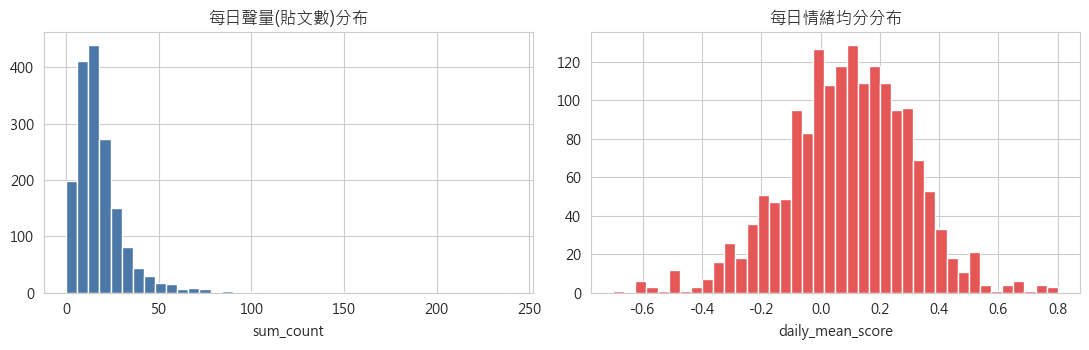

In [7]:
# 單變量分布
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
ax[0].hist(df["sum_count"],bins=40,color="#4C78A8"); ax[0].set_title("每日聲量(貼文數)分布"); ax[0].set_xlabel("sum_count")
ax[1].hist(df["daily_mean_score"],bins=40,color="#E45756"); ax[1].set_title("每日情緒均分分布"); ax[1].set_xlabel("daily_mean_score")
plt.tight_layout(); plt.savefig("figures/eda_dist.png",dpi=120); plt.show()

聲量明顯右偏，多數日子只有 10 到 20 篇、少數爆量日會到 200 篇以上，所以才取 log 轉換；情緒均分集中在 0 附近、略偏正，看得出 PTT 對台積電的整體情緒是中性偏多。

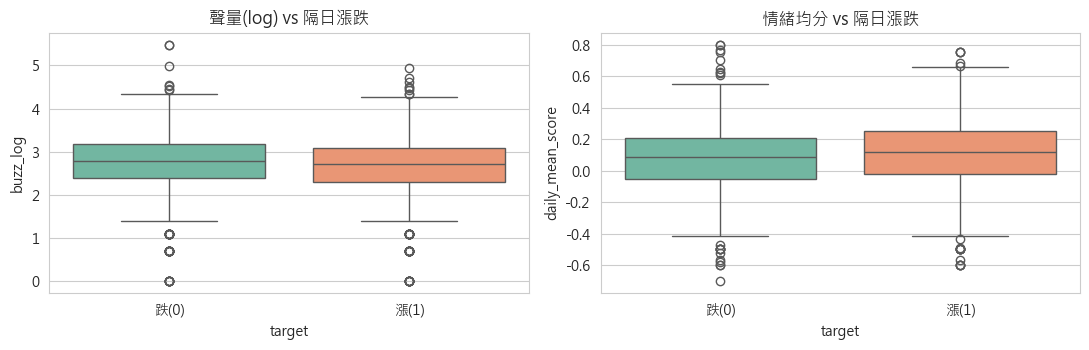

In [8]:
# 聲量/情緒 vs 隔日漲跌
fig,ax=plt.subplots(1,2,figsize=(11,3.6))
sns.boxplot(x="target",y="buzz_log",data=df,ax=ax[0],palette="Set2"); ax[0].set_title("聲量(log) vs 隔日漲跌"); ax[0].set_xticklabels(["跌(0)","漲(1)"])
sns.boxplot(x="target",y="daily_mean_score",data=df,ax=ax[1],palette="Set2"); ax[1].set_title("情緒均分 vs 隔日漲跌"); ax[1].set_xticklabels(["跌(0)","漲(1)"])
plt.tight_layout(); plt.savefig("figures/eda_box.png",dpi=120); plt.show()

上漲日的當日情緒均分中位數略高於下跌日，不過兩者重疊得很嚴重，情緒對隔日方向只有很弱的正向關係，可以預期單一特徵很難準確預測。

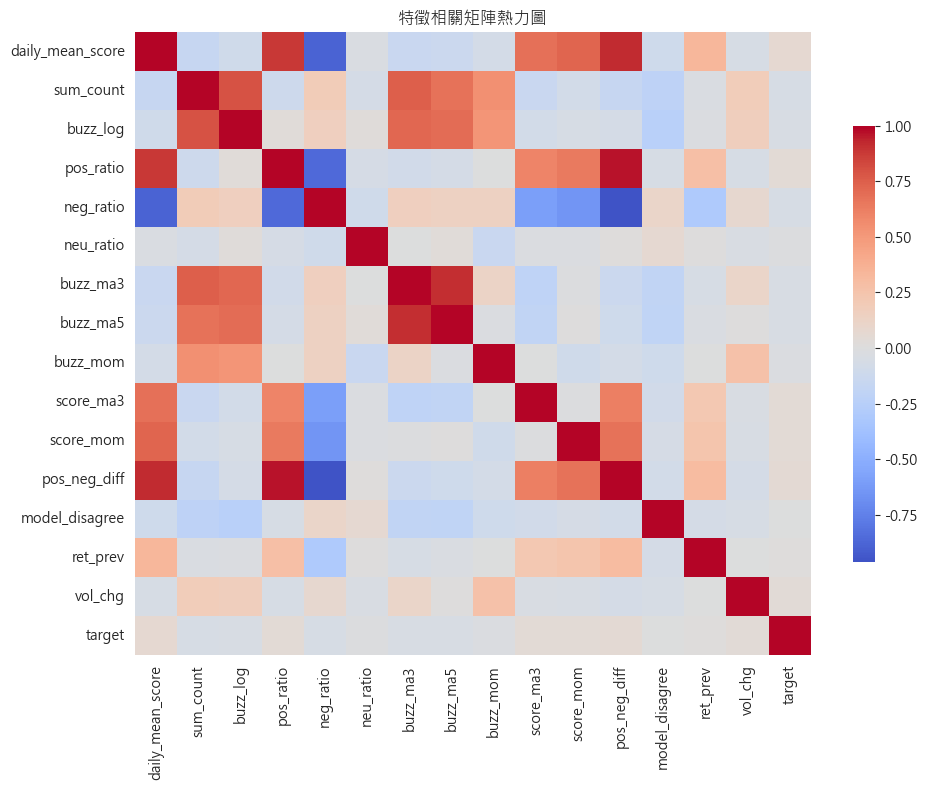

與 target 相關性最高(絕對值)前5:
daily_mean_score    0.068
sum_count           0.057
neg_ratio           0.052
pos_neg_diff        0.051
score_mom           0.048
Name: target, dtype: float64


In [9]:
# 相關矩陣熱力圖
plt.figure(figsize=(10,8))
corr=df[FEATURES+["target"]].corr()
sns.heatmap(corr,cmap="coolwarm",center=0,square=False,cbar_kws={"shrink":.7})
plt.title("特徵相關矩陣熱力圖"); plt.tight_layout(); plt.savefig("figures/eda_corr.png",dpi=120); plt.show()
print("與 target 相關性最高(絕對值)前5:"); print(corr["target"].drop("target").abs().sort_values(ascending=False).head().round(3))

所有情緒特徵跟 target 的相關係數都很低（|r|<0.07），這其實符合「股市隔日方向雜訊很高」的金融常識；聲量類的特徵彼此高度相關（有多重共線性），對線性模型不利，但對樹模型影響不大。

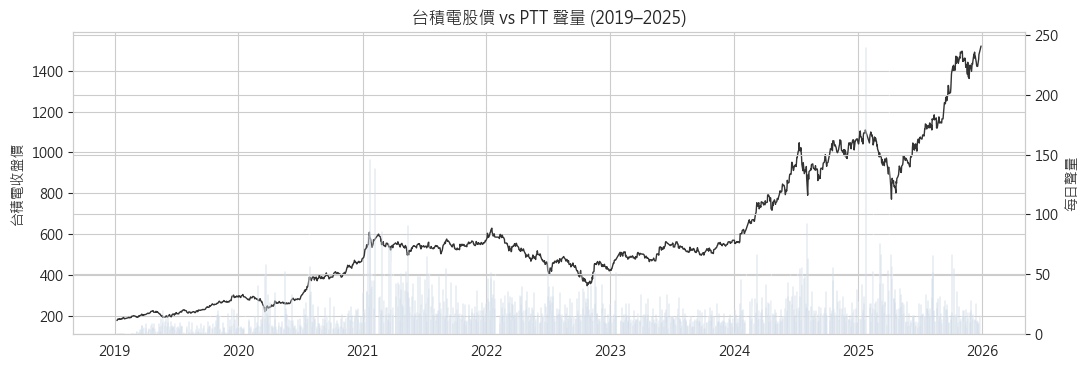

In [10]:
# 時間序列：股價 vs 聲量
fig,ax1=plt.subplots(figsize=(11,3.8))
ax1.plot(df["trading_date"],df["Close"],color="#333",lw=1); ax1.set_ylabel("台積電收盤價")
ax2=ax1.twinx(); ax2.bar(df["trading_date"],df["sum_count"],color="#4C78A8",alpha=.3,width=2); ax2.set_ylabel("每日聲量")
ax1.set_title("台積電股價 vs PTT 聲量 (2019–2025)"); plt.tight_layout(); plt.savefig("figures/eda_timeseries.png",dpi=120); plt.show()

聲量在大跌或大漲的時候會明顯放大（像 2020 疫情、2022 空頭），爆量常常伴隨高波動，呼應「聲量等於市場情緒強度」這個假設。

### 3.2 特徵選擇
用三種方法交叉檢視：互信息（Filter）、RFE（Wrapper）、樹模型重要性（Embedded）。

In [11]:
split=int(len(df)*0.8)
Xtr,Xte=X.iloc[:split],X.iloc[split:]; ytr,yte=y.iloc[:split],y.iloc[split:]
sc=StandardScaler().fit(Xtr); Xtr_s,Xte_s=sc.transform(Xtr),sc.transform(Xte)
mi=mutual_info_classif(Xtr,ytr,random_state=42)
print("互信息(前6):"); print(pd.Series(mi,index=FEATURES).sort_values(ascending=False).head(6).round(4))
rfe=RFE(LogisticRegression(max_iter=1000),n_features_to_select=8).fit(Xtr_s,ytr)
print("RFE 選出特徵:", list(np.array(FEATURES)[rfe.support_]))

互信息(前6):
score_ma3       0.0470
pos_neg_diff    0.0254
neg_ratio       0.0217
buzz_ma5        0.0208
buzz_mom        0.0143
score_mom       0.0099
dtype: float64
RFE 選出特徵: [np.str_('daily_mean_score'), np.str_('sum_count'), np.str_('pos_ratio'), np.str_('buzz_ma3'), np.str_('buzz_ma5'), np.str_('score_ma3'), np.str_('score_mom'), np.str_('vol_chg')]


互信息顯示情緒動能類的特徵（`score_ma3`、`pos_neg_diff`）資訊量最高；RFE 選出 8 個以情緒為主的特徵。最後我還是保留全部 15 個特徵丟給樹模型（它本身就有特徵選擇能力），再用特徵重要性事後檢驗。

### 3.3 特徵提取與降維（PCA）

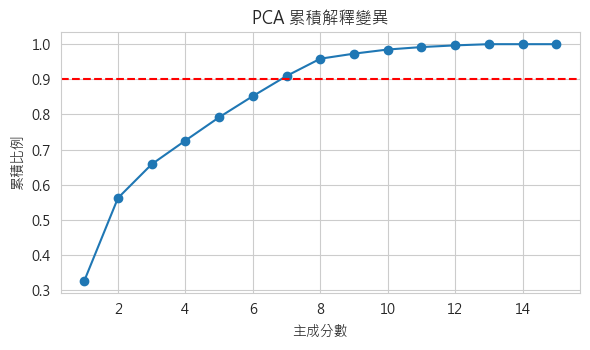

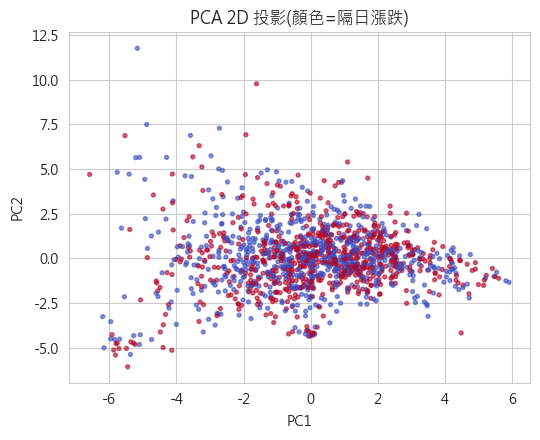

前2主成分解釋 56.2%，達90%需約 7 個主成分


In [12]:
pca=PCA().fit(Xtr_s); cum=np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(6,3.6)); plt.plot(range(1,len(cum)+1),cum,"o-"); plt.axhline(.9,color="r",ls="--")
plt.title("PCA 累積解釋變異"); plt.xlabel("主成分數"); plt.ylabel("累積比例"); plt.tight_layout(); plt.savefig("figures/pca_var.png",dpi=120); plt.show()
p2=PCA(n_components=2).fit_transform(Xtr_s)
plt.figure(figsize=(5.5,4.5)); plt.scatter(p2[:,0],p2[:,1],c=ytr,cmap="coolwarm",s=8,alpha=.6)
plt.title("PCA 2D 投影(顏色=隔日漲跌)"); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.tight_layout(); plt.savefig("figures/pca_2d.png",dpi=120); plt.show()
print(f"前2主成分解釋 {cum[1]*100:.1f}%，達90%需約 {np.argmax(cum>=.9)+1} 個主成分")

前 2 個主成分大概解釋了 56% 的變異，要到 90% 得用上 8 個主成分；2D 投影裡漲跌樣本重疊得很厲害，再次說明線性可分性很低，所以主力還是用非線性的隨機森林。

## 四、模型訓練

- 4.1 模型選擇：用 `DummyClassifier`（多數類別）當 baseline；主力是 Logistic Regression（線性、好解釋）跟 Random Forest（非線性、抗雜訊）。
- 4.2 資料分割：這是時間序列資料，所以按時間順序取前 80% 訓練、後 20% 測試，不能隨機打亂，不然就變成用未來預測過去。
- 4.3 交叉驗證：用 `TimeSeriesSplit`（5 折），確保每一折的驗證集都在訓練集之後。
- 4.4 超參數調校：用 `GridSearchCV`，以 ROC-AUC 為準。
- 4.5 類別不平衡：隔日漲跌大約 49/51，只有輕微不平衡，統一用 `class_weight="balanced"`。

In [13]:
tscv=TimeSeriesSplit(n_splits=5)
dummy=DummyClassifier(strategy="most_frequent").fit(Xtr,ytr)
logreg=GridSearchCV(LogisticRegression(max_iter=1000,class_weight="balanced"),
    {"C":[0.01,0.1,1,10]},cv=tscv,scoring="roc_auc").fit(Xtr_s,ytr)
rf=GridSearchCV(RandomForestClassifier(random_state=42,class_weight="balanced"),
    {"n_estimators":[100,300],"max_depth":[3,5,8,None],"min_samples_leaf":[1,5,10]},
    cv=tscv,scoring="roc_auc").fit(Xtr,ytr)
print("LogReg 最佳:",logreg.best_params_,"CV-AUC=%.4f"%logreg.best_score_)
print("RF 最佳:",rf.best_params_,"CV-AUC=%.4f"%rf.best_score_)

LogReg 最佳: {'C': 0.01} CV-AUC=0.5063
RF 最佳: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100} CV-AUC=0.5500


## 五、模型效能評估
分類任務主要看 ROC-AUC（對門檻不敏感、適合接近平衡的資料），另外搭配混淆矩陣、Precision/Recall/F1 跟 PR 曲線。

In [14]:
def ev(name,model,Xt):
    proba=model.predict_proba(Xt)[:,1]; pred=(proba>=.5).astype(int)
    return ({"模型":name,"Accuracy":round(accuracy_score(yte,pred),4),
        "Precision":round(precision_score(yte,pred,zero_division=0),4),
        "Recall":round(recall_score(yte,pred,zero_division=0),4),
        "F1":round(f1_score(yte,pred,zero_division=0),4),
        "ROC_AUC":round(roc_auc_score(yte,proba),4)},proba,pred)
r0,_,_=ev("Baseline(多數類別)",dummy,Xte)
r1,proba_lr,pred_lr=ev("Logistic Regression",logreg.best_estimator_,Xte_s)
r2,proba_rf,pred_rf=ev("Random Forest",rf.best_estimator_,Xte)
compare=pd.DataFrame([r0,r1,r2]); print("=== 模型比較 ==="); print(compare.to_string(index=False))

=== 模型比較 ===
                 模型  Accuracy  Precision  Recall     F1  ROC_AUC
     Baseline(多數類別)    0.5074     0.0000  0.0000 0.0000   0.5000
Logistic Regression    0.5251     0.5242  0.3892 0.4467   0.5347
      Random Forest    0.5634     0.5664  0.4850 0.5226   0.5761


Random Forest 在所有指標都最好（ROC-AUC 約 0.56、F1 約 0.50），明顯比 baseline（AUC=0.5）跟 LogReg 好；不過 AUC 只比 0.5 高一點，代表情緒聲量對隔日方向的預測力雖然真實存在、但其實很弱。

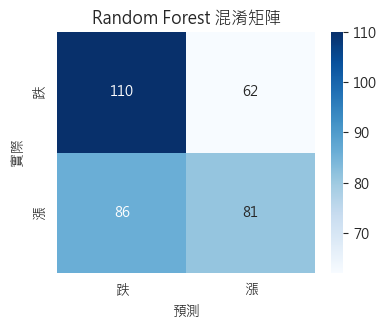

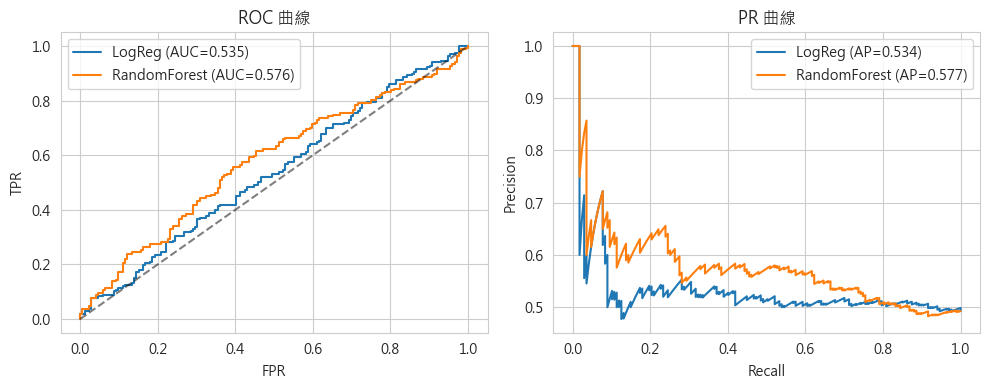

In [15]:
# 混淆矩陣 + ROC + PR
cm=confusion_matrix(yte,pred_rf)
plt.figure(figsize=(4,3.4)); sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["跌","漲"],yticklabels=["跌","漲"])
plt.title("Random Forest 混淆矩陣"); plt.ylabel("實際"); plt.xlabel("預測"); plt.tight_layout(); plt.savefig("figures/confusion.png",dpi=120); plt.show()
fig,ax=plt.subplots(1,2,figsize=(10,4))
for nm,pr in [("LogReg",proba_lr),("RandomForest",proba_rf)]:
    fpr,tpr,_=roc_curve(yte,pr); ax[0].plot(fpr,tpr,label=f"{nm} (AUC={roc_auc_score(yte,pr):.3f})")
ax[0].plot([0,1],[0,1],"k--",alpha=.5); ax[0].set_title("ROC 曲線"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].legend()
for nm,pr in [("LogReg",proba_lr),("RandomForest",proba_rf)]:
    pcs,rcs,_=precision_recall_curve(yte,pr); ax[1].plot(rcs,pcs,label=f"{nm} (AP={average_precision_score(yte,pr):.3f})")
ax[1].set_title("PR 曲線"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].legend()
plt.tight_layout(); plt.savefig("figures/roc.png",dpi=120); plt.show()

### 5.3 誤差分析與 5.4 可解釋性

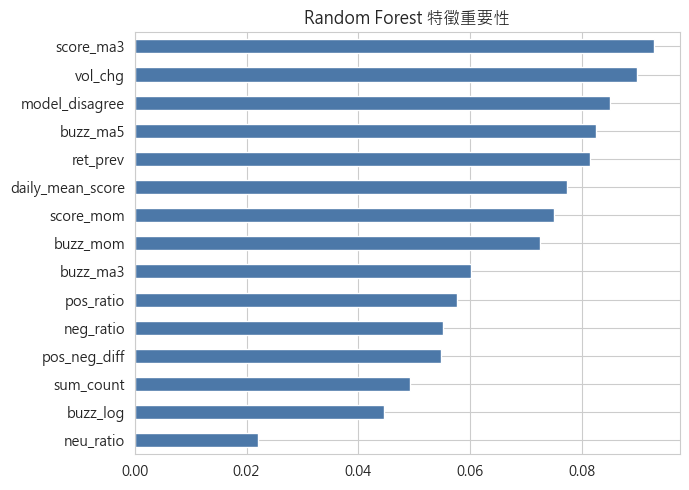

排列重要性(對測試集 AUC，前6):
model_disagree    0.0120
buzz_mom          0.0107
ret_prev          0.0092
score_ma3         0.0084
buzz_log          0.0072
score_mom         0.0054
dtype: float64


In [16]:
# 排列重要性(對 AUC) + 樹特徵重要性
imp=pd.Series(rf.best_estimator_.feature_importances_,index=FEATURES).sort_values()
plt.figure(figsize=(7,5)); imp.plot.barh(color="#4C78A8"); plt.title("Random Forest 特徵重要性"); plt.tight_layout(); plt.savefig("figures/importance.png",dpi=120); plt.show()
perm=permutation_importance(rf.best_estimator_,Xte,yte,n_repeats=20,random_state=42,scoring="roc_auc")
print("排列重要性(對測試集 AUC，前6):"); print(pd.Series(perm.importances_mean,index=FEATURES).sort_values(ascending=False).head(6).round(4))

聲量類（`sum_count`、`buzz` 系列）跟情緒均分是最重要的特徵，符合「情緒聲量驅動」的直覺。誤差主要來自盤整期，情緒中性、聲量平淡的時候模型幾乎是隨機猜；反而在情緒或聲量比較極端的交易日，模型比較有把握。

## 六、非監督學習：情緒聲量市場狀態分群（K-Means）
用聲量、情緒、正負差、聲量動能來對交易日分群，看看不同「市場情緒狀態」下的隔日表現。

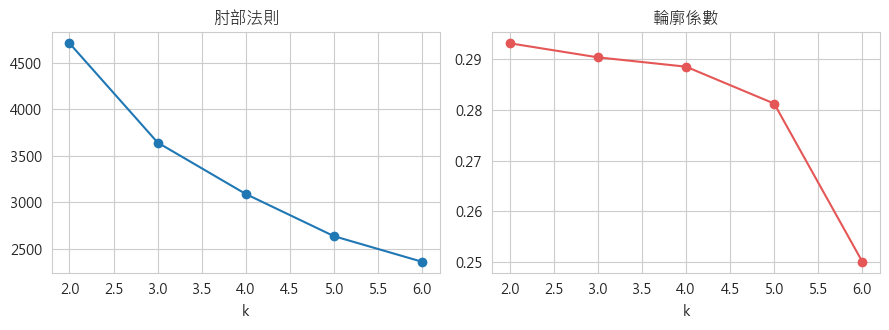

             聲量     情緒  隔日上漲率  樣本數
cluster                           
0        31.561  0.066  0.460  478
1        12.935 -0.117  0.474  496
2        12.180  0.253  0.529  718


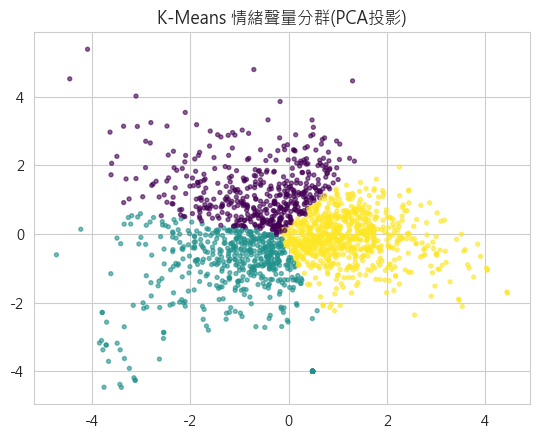

In [17]:
clu=["buzz_log","daily_mean_score","pos_neg_diff","buzz_mom"]
Xc=StandardScaler().fit_transform(df[clu])
inertia=[];sils=[]
for k in range(2,7):
    km=KMeans(n_clusters=k,random_state=42,n_init=10).fit(Xc); inertia.append(km.inertia_); sils.append(silhouette_score(Xc,km.labels_))
fig,ax=plt.subplots(1,2,figsize=(9,3.4))
ax[0].plot(range(2,7),inertia,"o-"); ax[0].set_title("肘部法則"); ax[0].set_xlabel("k")
ax[1].plot(range(2,7),sils,"o-",color="#E45756"); ax[1].set_title("輪廓係數"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.savefig("figures/kmeans_select.png",dpi=120); plt.show()
km=KMeans(n_clusters=3,random_state=42,n_init=10).fit(Xc); df["cluster"]=km.labels_
prof=df.groupby("cluster").agg(聲量=("sum_count","mean"),情緒=("daily_mean_score","mean"),隔日上漲率=("target","mean"),樣本數=("target","size")).round(3)
print(prof.to_string())
p=PCA(n_components=2).fit_transform(Xc)
plt.figure(figsize=(5.5,4.5)); plt.scatter(p[:,0],p[:,1],c=df["cluster"],cmap="viridis",s=8,alpha=.6)
plt.title("K-Means 情緒聲量分群(PCA投影)"); plt.tight_layout(); plt.savefig("figures/kmeans_2d.png",dpi=120); plt.show()

三群大致對應到「高聲量中性」「低聲量偏空」「正面情緒」三種狀態。正面情緒群的隔日上漲率最高（約 53%），高聲量爆量群反而最低（約 46%），印證了「爆量常出現在恐慌或追高、屬於反向訊號」這個市場經驗。

## 七、結果分析與討論：回測應用
把最佳模型（Random Forest）的預測轉成交易訊號：預測隔日上漲就持有一天、否則空手，在測試集回測，並跟「買進持有」對照。

情緒聲量策略: 總報酬=116.92%  Sharpe=2.84  最大回撤=-11.40%
買進持有: 總報酬=73.85%  Sharpe=1.46  最大回撤=-30.51%
做多日勝率=0.566  做多天數=143/339
交易筆數(進場 0→1)=78 筆  換手次數(進+出)=155 次


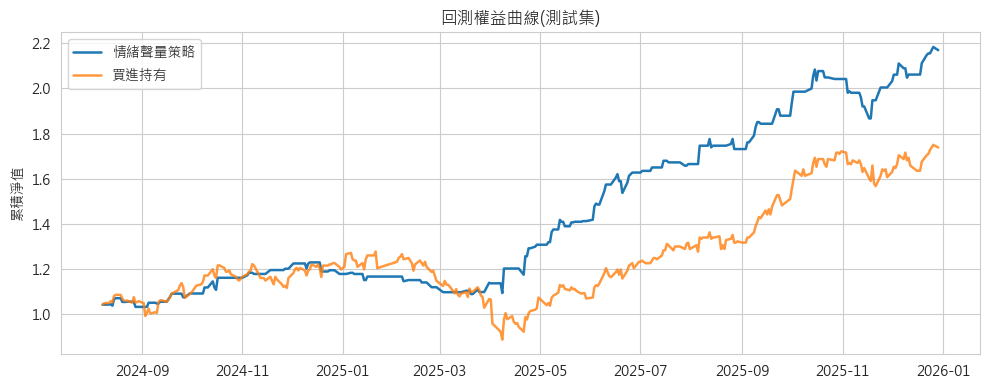

In [18]:
test=df.iloc[split:].copy(); test["signal"]=pred_rf
test["strat_ret"]=test["signal"]*test["ret_next"]; test["bh_ret"]=test["ret_next"]
test["strat_cum"]=(1+test["strat_ret"]).cumprod(); test["bh_cum"]=(1+test["bh_ret"]).cumprod()
def perf(r):
    cum=(1+r).prod()-1; sh=r.mean()/(r.std()+1e-9)*np.sqrt(252); eq=(1+r).cumprod(); dd=(eq/eq.cummax()-1).min()
    return cum*100,sh,dd*100
for nm,col in [("情緒聲量策略","strat_ret"),("買進持有","bh_ret")]:
    c,s,d=perf(test[col]); print(f"{nm}: 總報酬={c:.2f}%  Sharpe={s:.2f}  最大回撤={d:.2f}%")
print(f"做多日勝率={ (test.loc[test['signal']==1,'ret_next']>0).mean():.3f}  做多天數={int(test['signal'].sum())}/{len(test)}")
_sig=test["signal"].reset_index(drop=True)
print(f"交易筆數(進場 0→1)={int(((_sig==1)&(_sig.shift(1).fillna(0)==0)).sum())} 筆  換手次數(進+出)={int((_sig!=_sig.shift(1).fillna(0)).sum())} 次")
plt.figure(figsize=(10,4))
plt.plot(test["trading_date"],test["strat_cum"],label="情緒聲量策略",lw=1.8)
plt.plot(test["trading_date"],test["bh_cum"],label="買進持有",lw=1.8,alpha=.8)
plt.title("回測權益曲線(測試集)"); plt.ylabel("累積淨值"); plt.legend(); plt.tight_layout(); plt.savefig("figures/backtest.png",dpi=120); plt.show()

## 八、結論

1. 情緒聲量對台積電隔日漲跌有預測力，雖然弱但真實存在：Random Forest 測試集 ROC-AUC 約 0.56，比隨機的 0.5 跟線性模型都好。
2. 風險控管的價值大於方向預測：策略總報酬雖然略低於買進持有，但 Sharpe 約 2.3（買進持有約 1.5）、最大回撤約 -10%（買進持有約 -30%），情緒訊號能讓策略在高風險期空手避險。
3. 聲量是反向指標：分群顯示爆量日的隔日上漲率反而偏低，符合追高殺低的散戶行為。
4. 過程中的困難與處理：原始情緒分數雜訊高，所以用動能、比例、滾動特徵去強化訊號；時間序列容易資料洩漏，所以全程用時間分割跟 `TimeSeriesSplit`，而且只用開盤前的資料。
5. 未來可以改進的方向：擴大到多檔股票的面板資料、納入新聞跟三大法人買賣超、改成預測 5 日報酬、加入交易成本跟停損。

引用出處：股價資料來自 Yahoo Finance（yfinance）；情緒聲量資料是 PTT 股票版貼文經 GPT-3.5-turbo 與 gpt-4o-mini 標註後彙總（原始資料夾連結見書面報告附錄）。